# Evaluacija

# Overfitting i underfitting

In [1]:
import numpy as np
import sklearn.model_selection as skms
import pandas as pd
import matplotlib.pyplot as plt

,ftr,tgt
0,-3.684211,25.362712
1,-5.789474,65.817593
2,-4.736842,41.821279
3,6.842105,91.384318
4,8.947368,156.898291
5,-10.000000,197.002954
6,4.736842,42.652591
7,3.684211,22.412564
8,2.631579,11.041052
9,-2.631579,10.454338


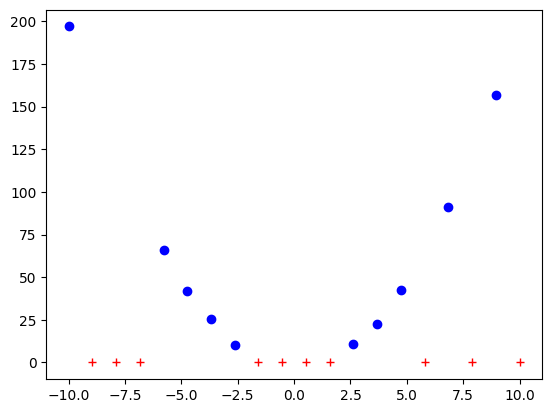

In [13]:
N = 20
ftr = np.linspace(-10, 10, num=N)
#print(ftr)

tgt = 2*ftr**2 -3 + np.random.uniform(-2, 2, N)
#print(tgt)

(train_ftr, test_ftr, train_tgt, test_tgt) = skms.train_test_split(ftr, tgt, test_size=N//2)
display(pd.DataFrame({'ftr': train_ftr, 'tgt': train_tgt}))
plt.plot(train_ftr, train_tgt, 'bo')
plt.plot(test_ftr, np.zeros_like(test_ftr), 'r+')

In [14]:
import sklearn.linear_model as linear_model

In [16]:
sk_model = linear_model.LinearRegression()
sk_model.fit(train_ftr.reshape(-1,1), train_tgt)
sk_preds=sk_model.predict(test_ftr.reshape(-1,1))
sk_preds[:]
#print(sk_model.coef_)
#print(sk_model.intercept_) #regresija na parabolu

array([57.03009198, 74.9442171 , 67.97761289, 61.01100868, 72.95375876,
       73.94898793, 65.98715454, 59.02055033, 66.98238372, 64.99192537])

In [18]:
model_one = np.poly1d(np.polyfit(train_ftr, train_tgt, 1)) # 1 == polinom prvog stupnja
preds_one = model_one(test_ftr)
print(preds_one)

[57.03009198 74.9442171  67.97761289 61.01100868 72.95375876 73.94898793
 65.98715454 59.02055033 66.98238372 64.99192537]


In [19]:
# Greška modela

In [20]:
from sklearn import metrics

In [21]:
print(np.allclose(sk_preds, preds_one)) #metoda koja uspoređuje dva broja, vraća true ili false
mse = metrics.mean_squared_error
print(np.sqrt(mse(test_tgt, preds_one)))

True
70.95087714129268


In [33]:
model_two = np.poly1d(np.polyfit(train_ftr, train_tgt, 2)) # dajemo mu da crta parabolu >> može se raširiti na dva stupnja
preds_two = model_two(test_ftr)
print(preds_two)

[196.87194634 157.66507061   2.27605201  64.0602986   91.10767088
 122.17031702  -2.23184337 121.60190756  -2.19394941   2.16237012]


In [34]:
print(np.allclose(sk_preds, preds_two))
mse = metrics.mean_squared_error
print(np.sqrt(mse(test_tgt, preds_two)))

False
1.2263435696925682


In [35]:
model_three = np.poly1d(np.polyfit(train_ftr, train_tgt, 9))
preds_three = model_three(test_ftr)
print(preds_three)

[ 5.51387471e+02  3.32257557e+02 -1.27818343e-01  6.98253761e+01
  1.18071478e+02  2.20237545e+02 -1.03529777e+00  9.97632785e+01
 -3.58665794e+00  4.24469991e+00]


In [36]:
print(np.allclose(sk_preds, preds_three))
mse = metrics.mean_squared_error
print(np.sqrt(mse(test_tgt, preds_three)))

False
129.0970730310502


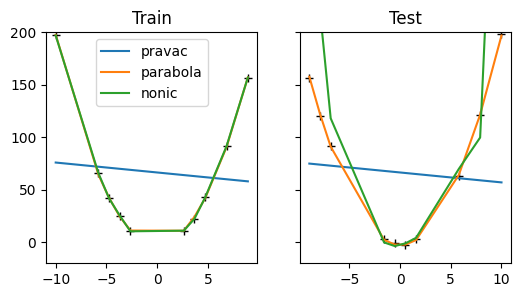

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
labels = ['pravac', 'parabola', 'nonic']
models = [model_one, model_two, model_three]
train = (train_ftr, train_tgt)
test = (test_ftr, test_tgt)
for ax, (ftr, tgt) in zip(axes, [train, test]):
  ax.plot(ftr, tgt, 'k+')
  for m, lbl in zip(models, labels):
    ftr = sorted(ftr)
    ax.plot(ftr, m(ftr), '-', label=lbl)
axes[1].set_ylim(-20, 200)
axes[0].set_title("Train")
axes[1].set_title("Test");
axes[0].legend(loc='upper center')

             Train Error  Test Error
Complexity                          
1           6.045128e+01   70.950877
2           8.992342e-01    1.226344
6           6.950197e-01    2.908146
7           6.850987e-01    3.393164
8           6.651366e-01   10.363336
9           8.439516e-13  129.097073


<Axes: xlabel='Complexity'>

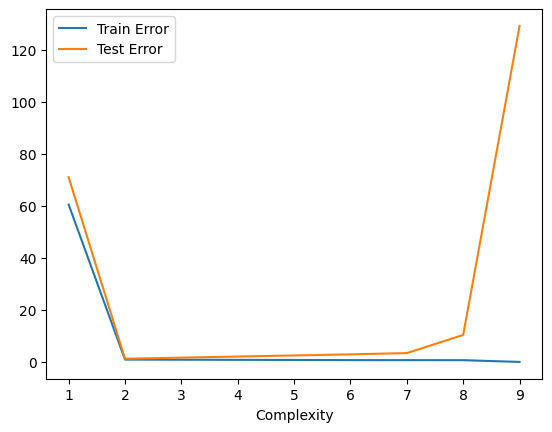

In [39]:
results = []
for complexity in [1, 2, 6, 7, 8, 9]:
  model = np.poly1d(np.polyfit(train_ftr, train_tgt, complexity))
  train_error = np.sqrt(mse(train_tgt, model(train_ftr)))
  test_error = np.sqrt(mse(test_tgt, model(test_ftr)))
  results.append((complexity, train_error, test_error))
columns = ["Complexity", "Train Error", "Test Error"]
results_df = pd.DataFrame.from_records(results,
columns=columns,
index="Complexity")
print(results_df)
results_df.plot()

# Funkcija gubitka

In [40]:
def training_loss(loss, model, training_data):
  return sum(loss(model.predict(x.reshape(1,-1)), y) for x, y in training_data)

In [41]:
def sqrt_error(prediction, actual):
  return (prediction - actual)**2

In [42]:
import numpy as np
from sklearn import neighbors, datasets

In [44]:
diabetes = datasets.load_diabetes()
knn = neighbors.KNeighborsRegressor()
fit =  knn.fit(diabetes.data, diabetes.target)
training_data = zip(diabetes.data, diabetes.target)
my_train_loss = training_loss(sqrt_error, knn, training_data)
print(my_train_loss)

[1035409.72]


In [46]:
mse = metrics.mean_squared_error(diabetes.target, knn.predict(diabetes.data))
print(mse*len(diabetes.data))

1035409.72


# Funkcija troška

# Score (rezultat ili funkcija bodovanja)

#Reuzorkovanje -> iz manje napraviti više -> train_test_split()

#K validation

In [48]:
from sklearn import datasets, neighbors, metrics, model_selection as skms

In [56]:
diabetes = datasets.load_diabetes()
model = neighbors.KNeighborsRegressor()
scores = skms.cross_val_score(model, diabetes.data, diabetes.target, cv=5, scoring='neg_mean_squared_error')
print(scores)
print(scores.mean())
print(scores.std())

[-3167.19191011 -4022.18067416 -3556.56681818 -3551.07136364
 -3807.57      ]
-3620.916153217569
286.61391962577613


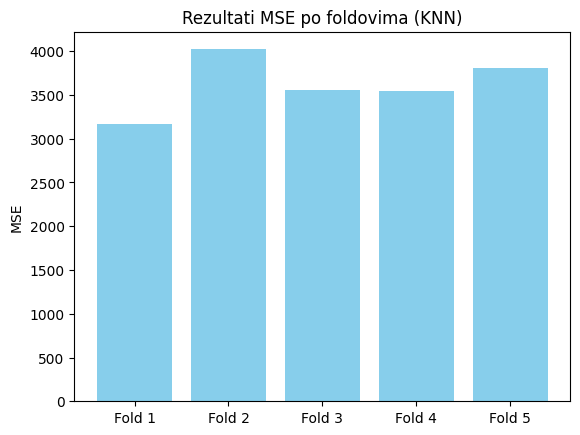

In [57]:
import matplotlib.pyplot as plt
# Pretvorba negativnog MSE u pozitivni MSE
mse_scores = -scores
# Kategorije za stupce
folds = [f"Fold {i+1}" for i in range(len(mse_scores))]
# Crtanje stupčastog grafikona
plt.bar(folds, mse_scores, color='skyblue')
plt.ylabel("MSE")
plt.title("Rezultati MSE po foldovima (KNN)")
plt.show()


# Stratifikacija

In [59]:
from sklearn import datasets, neighbors, metrics, model_selection as skms
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10)
non_strat_kf = skms.KFold(5)
izlaz1 = skms.cross_val_score(model, iris.data, iris.target, cv=non_strat_kf)
print(izlaz1)

izlaz2 = skms.cross_val_score(model, iris.data, iris.target, cv=5)
print(izlaz2)

[1.         1.         0.86666667 0.96666667 0.76666667]
[0.96666667 1.         1.         0.93333333 1.        ]


Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,50.179575,52.082634,52.802695,55.201171,55.71883,56.641006,56.793718,56.99524,57.721284,59.267713


<Axes: ylabel='RMSE'>

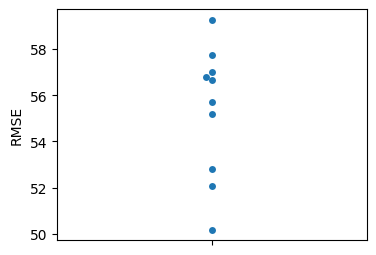

In [64]:
from sklearn import datasets, neighbors, metrics, model_selection as skms
from sklearn import linear_model
import seaborn as sns
linreg=linear_model.LinearRegression()
diabetes=datasets.load_diabetes()
scores=[]
for r in range (10):
  tts=skms.train_test_split(diabetes.data, diabetes.target, test_size=0.25)
  (diabetes_train_ftrs, diabetes_test_ftrs, diabetes_train_tgts, diabetes_test_tgts)=tts
  fit=linreg.fit(diabetes_train_ftrs, diabetes_train_tgts)
  preds=fit.predict(diabetes_test_ftrs)
  score = metrics.mean_squared_error(diabetes_test_tgts, preds)
  scores.append(score)
scores=pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE': scores})
df.index.name='Repeat'
display(df.T)
ax=plt.figure(figsize=(4,3)).gca()
sns.swarmplot(y='RMSE', data=df, ax=ax)

Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,0.668982,0.685609,0.689365,0.695924,0.711298,0.713411,0.716799,0.733927,0.74433,0.748604


<Axes: ylabel='RMSE'>

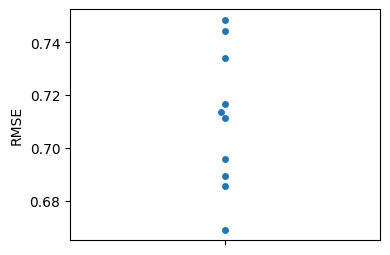

In [66]:
from sklearn import datasets, neighbors, metrics, model_selection as skms
from sklearn import linear_model
import seaborn as sns
linreg=linear_model.LinearRegression()
diabetes=datasets.load_diabetes()
scores=[]

ss = skms.ShuffleSplit(test_size=0.25)

scores = skms.cross_val_score(linreg, diabetes.data, diabetes.target, cv=ss)


scores=pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE': scores})
df.index.name='Repeat'
display(df.T)
ax=plt.figure(figsize=(4,3)).gca()
sns.swarmplot(y='RMSE', data=df, ax=ax)

# Leave one out cross validation

,count,mean,std,min,25%,50%,75%,max
RMSE,442.0,44.355723,32.19733,0.208637,18.485262,39.548204,63.974315,158.233013


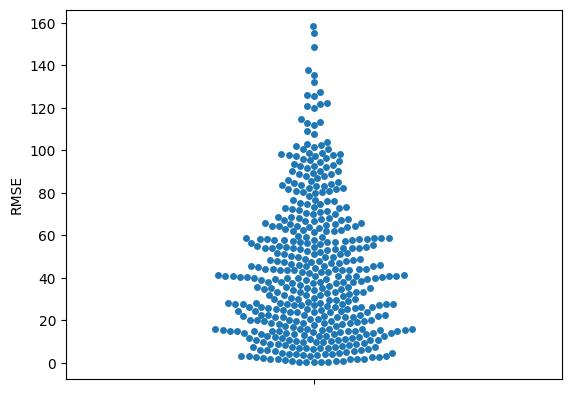

In [70]:
from sklearn import datasets, neighbors, metrics, model_selection as skms
from sklearn import linear_model
import seaborn as sns
linreg=linear_model.LinearRegression()
diabetes=datasets.load_diabetes()
scores=[]
loo=skms.LeaveOneOut()
#ss=skms.ShuffleSplit(test_size=0.25)
scores = skms.cross_val_score(linreg, diabetes.data, diabetes.target, cv=loo, scoring='neg_mean_squared_error')
#scores = skms.cross_val_score(linreg, diabetes.data, diabetes.target, cv=ss, scoring='neg_mean_squared_error'
scores=pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE': scores})
df.index.name='Repeat'
display(df.describe().T)
#ax=plt.figure(figsize=(4,3)).gca()
ax = sns.swarmplot(y='RMSE', data=df)

# Krivulje učenja: Koliko podataka trebamo?

In [71]:
from sklearn import datasets
from sklearn import neighbors
from sklearn import model_selection as skms
import numpy as np
import pandas as pd
iris = datasets.load_iris()
# 10 podatkovnih skupova velicine: 10% - 100%
# (5-fold CV)
train_sizes = np.linspace(.1, 1.0, 10)
nn = neighbors.KNeighborsClassifier()
(train_N, train_scores, test_scores) = skms.learning_curve(nn,
  iris.data, iris.target,
  cv=5, train_sizes=train_sizes)
# sažeti kroz 5 CV rezultata; jedan rezultat za svaku veličinu skupa podataka
df = pd.DataFrame(test_scores, index=(train_sizes*100).astype(int))
df['Mean 5-CV'] = df.mean(axis='columns')
df.index.name = "% Data Used"
display(df)

,0,1,2,3,4,Mean 5-CV
% Data Used,,,,,,
10,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
20,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
30,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
40,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
50,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
60,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
70,0.900000,0.800000,0.833333,0.866667,0.800000,0.840000
80,0.966667,0.933333,0.900000,0.900000,0.966667,0.933333
90,0.966667,1.000000,0.900000,0.966667,1.000000,0.966667


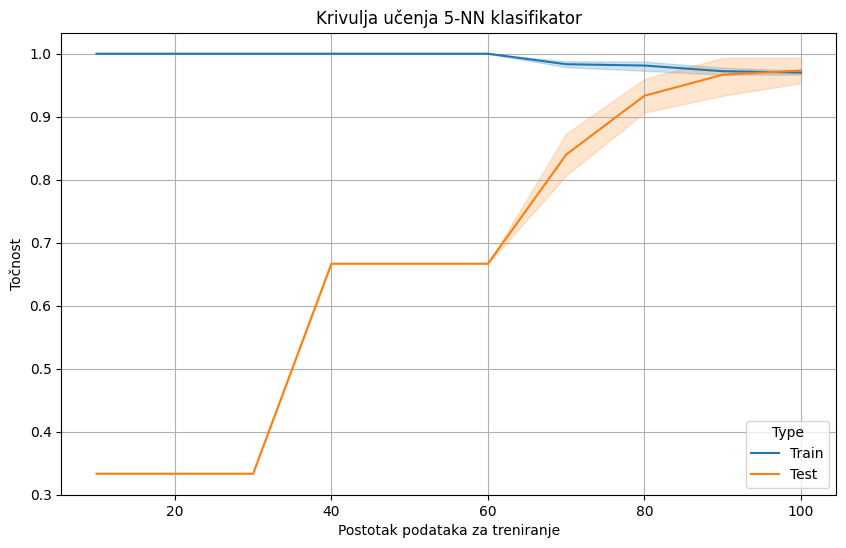

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# kreiraj dataframe iz rezultata
train_df = pd.DataFrame(train_scores)
test_df = pd.DataFrame(test_scores)
# dodaj stupac za veličine skupova za treniranje
train_df['Data Used (%)'] = train_sizes * 100
test_df['Data Used (%)'] = train_sizes * 100
# dodaj stupac Train/Test
train_df['Type'] = 'Train'
test_df['Type'] = 'Test'
# Pretvori DataFrames u dugi format
train_melted = train_df.melt(id_vars=['Data Used (%)', 'Type'], var_name='Fold', value_name='Accuracy')
test_melted = test_df.melt(id_vars=['Data Used (%)', 'Type'], var_name='Fold', value_name='Accuracy')
# Spojite DataFrameove
combined_df = pd.concat([train_melted, test_melted])
# Crtanje sa lineplot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=combined_df, x='Data Used (%)', y='Accuracy', hue='Type')
ax.set_title("Krivulja učenja 5-NN klasifikator")
ax.set_xlabel("Postotak podataka za treniranje")
ax.set_ylabel("Točnost")
plt.grid(True)
plt.show()

# Krivulje složenosti